# Comparación de Modelos de Ensamble

En este laboratorio comparamos las tres familias de **ensambles** vistas en clase
(*bagging*, *Random Forests* y *boosting*) frente a un modelo base inestable
(un único árbol de decisión).

La idea central es el **compromiso sesgo–varianza**: un árbol profundo tiene poco
sesgo pero mucha varianza (sobre-ajusta). Los ensambles buscan *romper* ese
compromiso:

- **Bagging** entrena modelos en paralelo sobre muestras *bootstrap* y promedia
  $\Rightarrow$ reduce la **varianza**.
- **Random Forests** añaden aleatoriedad de variables ($m$ de $p$) para
  *des-correlacionar* los árboles y reducir aún más la varianza.
- **Boosting** ajusta modelos débiles de forma secuencial, cada uno corrigiendo
  los errores del anterior $\Rightarrow$ reduce el **sesgo**.

Todos los modelos se ajustan dentro de un `Pipeline` y sus hiper-parámetros se
buscan con `RandomizedSearchCV`.

## 1. Importar librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Generar datos simulados

Construimos un problema de clasificación binaria de dimensión moderada con
`make_classification`: 20 variables, de las cuales sólo 8 son informativas y 4
redundantes. Añadimos algo de ruido en las etiquetas (`flip_y`) para que ningún
modelo pueda ser perfecto, de modo que la comparación entre ensambles sea
significativa.

In [2]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    class_sep=0.8,
    flip_y=0.05,
    random_state=RANDOM_STATE,
)
print(f"X: {X.shape}")
print(f"Distribución de clases: {np.bincount(y)}")

X: (2000, 20)
Distribución de clases: [1004  996]


## 2.1 Dividir datos en conjunto de entrenamiento y prueba

Separamos 70/30 manteniendo la proporción de clases con `stratify=y`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 1400 muestras
Prueba:        600 muestras


## 3. Modelo base: un único árbol de decisión

Los árboles de decisión son modelos **inestables**: pequeños cambios en los datos
producen árboles muy distintos (alta varianza). Un árbol sin podar tiende a
*memorizar* el entrenamiento. Lo usamos como línea base para medir cuánto aportan
los ensambles.

Aunque los árboles no requieren escalado, envolvemos el modelo en un `Pipeline`
con `StandardScaler` para mantener una estructura homogénea con el resto de los
modelos.

In [4]:
arbol = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
arbol.fit(X_train, y_train)

acc_train = accuracy_score(y_train, arbol.predict(X_train))
acc_test = accuracy_score(y_test, arbol.predict(X_test))
print(f"Árbol único -> train: {acc_train:.3f} | test: {acc_test:.3f}")
print(f"Brecha train-test: {acc_train - acc_test:.3f}  (síntoma de sobre-ajuste / alta varianza)")

Árbol único -> train: 1.000 | test: 0.707
Brecha train-test: 0.293  (síntoma de sobre-ajuste / alta varianza)


## 4. Definir los ensambles dentro de un Pipeline

Definimos las tres familias de ensambles, cada una dentro de un `Pipeline`, y
las distribuciones de hiper-parámetros que exploraremos. Usamos el prefijo
`clf__` para apuntar al paso del clasificador dentro del pipeline.

- **Bagging**: número de modelos y fracción de muestras/variables por modelo.
- **Random Forest**: número de árboles, profundidad y `max_features` (controla la
  des-correlación; `"sqrt"` $\approx \sqrt{p}$, el valor típico en clasificación).
- **AdaBoost**: número de etapas y `learning_rate`.
- **Gradient Boosting**: número de árboles, `learning_rate`, profundidad (modelos
  *débiles*, poco profundos) y `subsample`.

In [5]:
modelos = {
    "Bagging": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    "AdaBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", AdaBoostClassifier(random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

distribuciones = {
    "Bagging": {
        "clf__n_estimators": randint(50, 300),
        "clf__max_samples": uniform(0.5, 0.5),
        "clf__max_features": uniform(0.5, 0.5),
    },
    "Random Forest": {
        "clf__n_estimators": randint(100, 500),
        "clf__max_depth": randint(3, 20),
        "clf__max_features": ["sqrt", "log2", 0.5],
        "clf__min_samples_leaf": randint(1, 10),
    },
    "AdaBoost": {
        "clf__n_estimators": randint(50, 300),
        "clf__learning_rate": loguniform(1e-2, 1.0),
    },
    "Gradient Boosting": {
        "clf__n_estimators": randint(100, 400),
        "clf__learning_rate": loguniform(1e-2, 0.3),
        "clf__max_depth": randint(2, 5),
        "clf__subsample": uniform(0.6, 0.4),
    },
}

## 5. Ajuste de hiper-parámetros con RandomizedSearchCV

Para cada modelo realizamos una búsqueda aleatoria de 20 combinaciones con
validación cruzada de 5 particiones, optimizando la *accuracy*. `RandomizedSearchCV`
ajusta automáticamente todo el `Pipeline` en cada partición, evitando fugas de
información del escalado.

In [6]:
resultados = {}
for nombre, pipe in modelos.items():
    busqueda = RandomizedSearchCV(
        pipe,
        param_distributions=distribuciones[nombre],
        n_iter=20,
        cv=5,
        scoring="accuracy",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    busqueda.fit(X_train, y_train)
    resultados[nombre] = busqueda
    print(f"{nombre:18s} | CV acc: {busqueda.best_score_:.3f}")
    print(f"{'':18s}   mejores params: {busqueda.best_params_}")

Bagging            | CV acc: 0.828
                     mejores params: {'clf__max_features': np.float64(0.6872700594236812), 'clf__max_samples': np.float64(0.9753571532049581), 'clf__n_estimators': 156}


Random Forest      | CV acc: 0.830
                     mejores params: {'clf__max_depth': 11, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 487}


AdaBoost           | CV acc: 0.704
                     mejores params: {'clf__learning_rate': np.float64(0.2607024758370766), 'clf__n_estimators': 199}


Gradient Boosting  | CV acc: 0.816
                     mejores params: {'clf__learning_rate': np.float64(0.07661100707771368), 'clf__max_depth': 4, 'clf__n_estimators': 221, 'clf__subsample': np.float64(0.662397808134481)}


## 6. Error out-of-bag (OOB) vs número de árboles

Cada muestra *bootstrap* deja fuera $\approx 37\%$ de las observaciones. Esos datos
*out-of-bag* permiten estimar el error de generalización **sin** un conjunto de
validación aparte. Reproducimos la curva clásica *error vs número de árboles*:
el error cae rápido y luego se estabiliza, por lo que añadir más árboles no
sobre-ajusta (sólo cuesta cómputo).

/Users/sergio/code/Machine_Learning_MDS211/env/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/sergio/code/Machine_Learning_MDS211/env/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


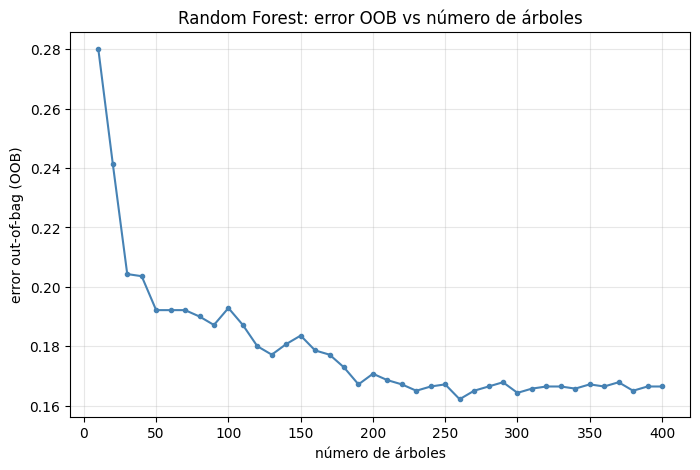

In [7]:
n_arboles = list(range(10, 401, 10))
oob_errores = []

rf_oob = RandomForestClassifier(
    warm_start=True,
    oob_score=True,
    max_features="sqrt",
    random_state=RANDOM_STATE,
)
for n in n_arboles:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train, y_train)
    oob_errores.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(n_arboles, oob_errores, marker=".", color="steelblue")
plt.xlabel("número de árboles")
plt.ylabel("error out-of-bag (OOB)")
plt.title("Random Forest: error OOB vs número de árboles")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Comparar desempeño en el conjunto de prueba

Evaluamos en el conjunto de prueba el árbol base y los cuatro ensambles ya
optimizados.

Árbol único        | test acc: 0.707
Bagging            | test acc: 0.808
Random Forest      | test acc: 0.805
AdaBoost           | test acc: 0.717
Gradient Boosting  | test acc: 0.812


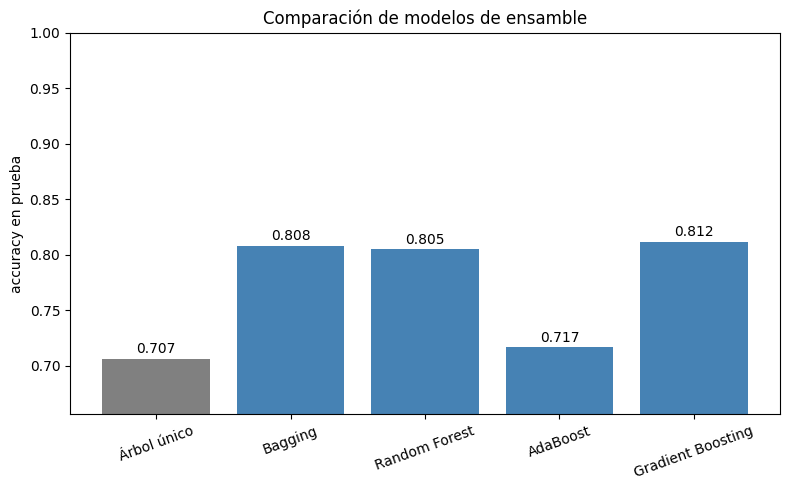

In [8]:
nombres, acc_tests = [], []

acc_arbol = accuracy_score(y_test, arbol.predict(X_test))
nombres.append("Árbol único")
acc_tests.append(acc_arbol)
print(f"{'Árbol único':18s} | test acc: {acc_arbol:.3f}")

for nombre, busqueda in resultados.items():
    acc = accuracy_score(y_test, busqueda.predict(X_test))
    nombres.append(nombre)
    acc_tests.append(acc)
    print(f"{nombre:18s} | test acc: {acc:.3f}")

plt.figure(figsize=(8, 5))
colores = ["gray"] + ["steelblue"] * (len(nombres) - 1)
plt.bar(nombres, acc_tests, color=colores)
plt.ylabel("accuracy en prueba")
plt.ylim(min(acc_tests) - 0.05, 1.0)
plt.title("Comparación de modelos de ensamble")
plt.xticks(rotation=20)
for i, v in enumerate(acc_tests):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

### 7.1 Reporte detallado del mejor modelo

In [9]:
mejor = max(resultados, key=lambda k: accuracy_score(y_test, resultados[k].predict(X_test)))
print(f"Mejor modelo: {mejor}\n")
print(classification_report(y_test, resultados[mejor].predict(X_test)))

Mejor modelo: Gradient Boosting

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       301
           1       0.81      0.82      0.81       299

    accuracy                           0.81       600
   macro avg       0.81      0.81      0.81       600
weighted avg       0.81      0.81      0.81       600



## 8. Importancia de variables (Random Forest)

Una ventaja práctica de los Random Forests es que entregan una medida de
**importancia de variables** (cuánto baja la impureza al usar cada variable),
lo que aporta interpretabilidad. Las variables informativas deberían destacar
sobre las de ruido.

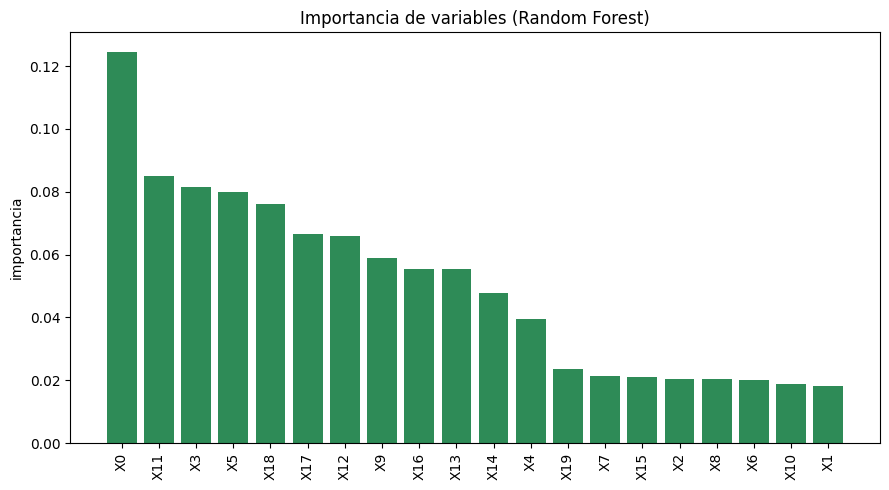

In [10]:
rf_best = resultados["Random Forest"].best_estimator_.named_steps["clf"]
importancias = rf_best.feature_importances_
orden = np.argsort(importancias)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(importancias)), importancias[orden], color="seagreen")
plt.xticks(range(len(importancias)), [f"X{i}" for i in orden], rotation=90)
plt.ylabel("importancia")
plt.title("Importancia de variables (Random Forest)")
plt.tight_layout()
plt.show()

## 9. Conclusiones

| | **Bagging** | **Boosting** |
|---|---|---|
| Entrenamiento | Paralelo | Secuencial |
| Objetivo | Reducir **varianza** | Reducir **sesgo** |
| Modelos base | Fuertes (profundos) | Débiles (poco profundos) |
| Ponderación | Uniforme | Según desempeño |
| Riesgo | Robusto | Puede sobre-ajustar |

- Todos los ensambles superan claramente al **árbol único**, confirmando que
  combinar modelos reduce el error.
- **Bagging / Random Forests** son rápidos, robustos y un excelente punto de
  partida; el error OOB se estabiliza y no sobre-ajusta al añadir árboles.
- **Boosting** suele dar la mayor exactitud, pero a costa de un ajuste más
  cuidadoso de hiper-parámetros (sobre todo `learning_rate`).
- El uso de un `Pipeline` + `RandomizedSearchCV` garantiza una comparación justa:
  el preprocesamiento se ajusta dentro de cada partición de validación cruzada.